# Trabalho de Banco de Dados II - Polymarket no BigQuery

## Importações de bibliotecas

In [57]:
import pandas as pd
import matplotlib.pyplot as plt


## 1. Introdução

O evento analisado foi série recorrente de mercados de "Bitcoin Up or Down de 5min em 5min". Ao contrário de eventos que possuem um único mercado, esse evento é composto por uma grande quantidade de instâncias da mesma família de mercado.

**Pergunta central:** os mercados de Bitcoin de 5 min estão bem calibrados nos casos de alta confiança, e o volume negociado tem padrões repetitivos (hora/dia da semana) e anomalias em seu comportamento?

**Hipóteses:**
- Hipótese de calibração: em janelas de alta confiança, os erros de calibração são raros.
- Hipótese de volume: o volume varia por hora/dia, e janelas com volume mais alto tendem a ter maior oscilação de preço dentro da própria janela de 5 minutos.

## 2. Exploração inicial

Antes de restringir a análise a uma família específica de mercado, realizei uma busca para localizar os mercados relacionados a "Bitcoin Up or Down", filtrando pelo texto da pergunta. Essa busca foi o que me levou a identificar o padrão de slug btc-updown-5m-, usado no restante da análise.

```sql
SELECT DISTINCT slug, question, end_date
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%bitcoin%up or down%'
ORDER BY end_date DESC
LIMIT 50;
```

In [58]:
df_familias_mercado = pd.read_csv('dados/familias_mercado.csv')
df_familias_mercado.head(30)

,slug,question,end_date
0,bitcoin-up-or-down-may-6-2026-11am-et,"Bitcoin Up or Down - May 6, 11AM ET",2026-05-06 16:00:00.000000 UTC
1,bitcoin-up-or-down-may-6-2026-10am-et,"Bitcoin Up or Down - May 6, 10AM ET",2026-05-06 15:00:00.000000 UTC
2,bitcoin-up-or-down-may-6-2026-9am-et,"Bitcoin Up or Down - May 6, 9AM ET",2026-05-06 14:00:00.000000 UTC
3,bitcoin-up-or-down-may-6-2026-8am-et,"Bitcoin Up or Down - May 6, 8AM ET",2026-05-06 13:00:00.000000 UTC
4,bitcoin-up-or-down-may-6-2026-7am-et,"Bitcoin Up or Down - May 6, 7AM ET",2026-05-06 12:00:00.000000 UTC
5,bitcoin-up-or-down-may-6-2026-6am-et,"Bitcoin Up or Down - May 6, 6AM ET",2026-05-06 11:00:00.000000 UTC
6,bitcoin-up-or-down-may-6-2026-5am-et,"Bitcoin Up or Down - May 6, 5AM ET",2026-05-06 10:00:00.000000 UTC
7,bitcoin-up-or-down-may-6-2026-4am-et,"Bitcoin Up or Down - May 6, 4AM ET",2026-05-06 09:00:00.000000 UTC
8,bitcoin-up-or-down-may-6-2026-3am-et,"Bitcoin Up or Down - May 6, 3AM ET",2026-05-06 08:00:00.000000 UTC
9,bitcoin-up-or-down-may-6-2026-2am-et,"Bitcoin Up or Down - May 6, 2AM ET",2026-05-06 07:00:00.000000 UTC


A família btc-updown-5m se destacou tanto pelo número de instâncias (uma nova janela a cada 5 minutos, ao longo de meses) quanto pela regularidade do formato — cada mercado segue a mesma estrutura binária (Up/Down) e a mesma duração fixa, o que permite tratar as centenas de instâncias como uma amostra estatística comparável, em vez de eventos isolados.

Com a família de mercado escolhida, realizei uma busca filtrando pelo prefixo 'btc-updown-5m-", a fim de encontrar apenas os mercados que analisam bitcoin de 5 em 5 minutos.

```sql
SELECT
  market_id, slug, question, event_title, volume, created_at, end_date, closed, token1, token2, outcome_prices
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE slug LIKE 'btc-updown-5m-%'
ORDER BY end_date DESC;
```

In [59]:
df_exploracao_inicial = pd.read_csv('dados/exploracao_inicial.csv')
df_exploracao_inicial.head()


,market_id,slug,question,event_title,volume,created_at,end_date,closed,token1,token2,outcome_prices,answer1,answer2
0,2155641,btc-updown-5m-1777995600,"Bitcoin Up or Down - May 5, 11:40AM-11:45AM ET","Bitcoin Up or Down - May 5, 11:40AM-11:45AM ET",0.0,2026-05-04 15:46:54.000000 UTC,2026-05-05 15:45:00.000000 UTC,0,3765766705120037805128517194347704190658828298...,5567906445831013171644826463195448463678593354...,"['0.505', '0.495']",Up,Down
1,2155630,btc-updown-5m-1777995300,"Bitcoin Up or Down - May 5, 11:35AM-11:40AM ET","Bitcoin Up or Down - May 5, 11:35AM-11:40AM ET",0.0,2026-05-04 15:41:57.000000 UTC,2026-05-05 15:40:00.000000 UTC,0,1915242799801775856610950467962237518234230476...,1013508876064327676832163908707526098977095865...,"['0.505', '0.495']",Up,Down
2,2155591,btc-updown-5m-1777995000,"Bitcoin Up or Down - May 5, 11:30AM-11:35AM ET","Bitcoin Up or Down - May 5, 11:30AM-11:35AM ET",0.0,2026-05-04 15:36:58.000000 UTC,2026-05-05 15:35:00.000000 UTC,0,4671491445856824397211109014911739182643446599...,1076038820728189332897262274446721417258465818...,"['0.505', '0.495']",Up,Down
3,2155572,btc-updown-5m-1777994700,"Bitcoin Up or Down - May 5, 11:25AM-11:30AM ET","Bitcoin Up or Down - May 5, 11:25AM-11:30AM ET",0.0,2026-05-04 15:31:53.000000 UTC,2026-05-05 15:30:00.000000 UTC,0,7346518133553418492752246534520454548583978777...,3269264520431879345297654748463212938302248272...,"['0.505', '0.495']",Up,Down
4,2155372,btc-updown-5m-1777994400,"Bitcoin Up or Down - May 5, 11:20AM-11:25AM ET","Bitcoin Up or Down - May 5, 11:20AM-11:25AM ET",0.0,2026-05-04 15:26:52.000000 UTC,2026-05-05 15:25:00.000000 UTC,0,1726743542775144716317092995435051836298538488...,6828801913367418223536117892926906526244634488...,"['0.505', '0.495']",Up,Down


Após isso, adicionei um filtro para explorarmos apenas os mercados durante o mês de março desse ano.

```sql
SELECT
  market_id, slug, token1, token2, outcome_prices, volume, created_at, end_date
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE slug LIKE 'btc-updown-5m-%'
  AND closed = 1
  AND end_date IS NOT NULL
  AND end_date >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
  AND end_date <  TIMESTAMP('2026-03-31 00:00:00', 'America/New_York')
ORDER BY end_date;
```

Após achar o conjunto de mercados a serem analisados, rodei uma query para explorar as colunas da tabela de trades. Nesse exemplo, explorei um pouco dos primeiros 30 minutos do dia 1 de março de 2026.

```sql
SELECT
  trade_timestamp, market_id, asset_id, price, usd_amount, token_amount,
  maker_direction, taker_direction
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE market_id IN (
    SELECT market_id
    FROM `even-continuity-441808-j0.polymarket_optimized.markets`
    WHERE slug LIKE 'btc-updown-5m-%'
      AND closed = 1
      AND end_date >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
      AND end_date <  TIMESTAMP('2026-03-01 00:30:00', 'America/New_York')
  )
  AND trade_timestamp >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
  AND trade_timestamp <  TIMESTAMP('2026-03-01 00:30:00', 'America/New_York')
ORDER BY trade_timestamp
```

In [60]:
df_amostra_trades = pd.read_csv('dados/amostra_trades.csv')
df_amostra_trades.head(20)

,trade_timestamp,market_id,asset_id,price,usd_amount,token_amount,maker_direction,taker_direction
0,2026-03-01 05:00:01.000000 UTC,1462869,2665773661048584664427641315817193960554029444...,0.03,0.15,5.00,BUY,SELL
1,2026-03-01 05:00:01.000000 UTC,1462869,2665773661048584664427641315817193960554029444...,0.03,1.48,49.27,BUY,SELL
2,2026-03-01 05:00:01.000000 UTC,1462869,2665773661048584664427641315817193960554029444...,0.03,4.50,150.00,BUY,SELL
3,2026-03-01 05:00:01.000000 UTC,1462869,2665773661048584664427641315817193960554029444...,0.02,0.02,1.02,BUY,SELL
4,2026-03-01 05:00:01.000000 UTC,1462869,2665773661048584664427641315817193960554029444...,0.06,3.03,50.53,BUY,SELL
5,2026-03-01 05:00:01.000000 UTC,1462869,2665773661048584664427641315817193960554029444...,0.03,0.12,4.05,BUY,SELL
6,2026-03-01 05:00:01.000000 UTC,1462869,2665773661048584664427641315817193960554029444...,0.06,0.12,2.00,BUY,SELL
7,2026-03-01 05:00:01.000000 UTC,1462869,2665773661048584664427641315817193960554029444...,0.02,0.02,1.02,BUY,SELL
8,2026-03-01 05:00:01.000000 UTC,1462869,2665773661048584664427641315817193960554029444...,0.02,0.52,26.17,BUY,SELL
9,2026-03-01 05:00:01.000000 UTC,1462869,2665773661048584664427641315817193960554029444...,0.06,1.20,20.00,BUY,SELL


## 3. Agregações e subqueries de interesse

Para entender como o volume se distribui entre as janelas, rodei uma consulta separada pra descobrir os quartis de volume negociado por mercado, considerando apenas os mercados que tiveram alguma negociação no período.

```sql
WITH trades_janela AS (
  SELECT
    market_id,
    SUM(usd_amount) AS volume_janela
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  JOIN `even-continuity-441808-j0.polymarket_optimized.trades`
    USING (market_id)
  WHERE slug LIKE 'btc-updown-5m-%'
    AND closed = 1
    AND trade_timestamp >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
    AND trade_timestamp <  TIMESTAMP('2026-04-01 00:00:00', 'America/New_York')
    AND end_date >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
    AND end_date <  TIMESTAMP('2026-04-01 00:00:00', 'America/New_York')
  GROUP BY market_id
)
SELECT
  APPROX_QUANTILES(volume_janela, 4) AS quartis_de_volume
FROM trades_janela
WHERE volume_janela > 0;
```

In [61]:
df_quartis_volume = pd.read_csv('dados/quartis_volume.csv')

valores = df_quartis_volume['quartis_de_volume'].str.strip('[]').str.split(',', expand=True).astype(float)
valores


,0,1,2,3,4
0,1.37,55943.01,69572.55,86670.89,1155199.96


Os cortes retornados (aproximadamente 55,943, 69,572 e 86,671) foram os valores usados pra definir as faixas de volume da consulta seguinte.

Com os quatro cortes em mãos, defini três faixas de volume (abaixo do primeiro quartil, entre o primeiro e o terceiro, e acima do terceiro), além de uma faixa separada para os mercados sem nenhum trade no período. A partir daí, agreguei a oscilação de preço e a quantidade de trades por faixa.

```sql
WITH agregacao_mercados AS (
  SELECT
    mercado.market_id,
    COALESCE(SUM(transacao.usd_amount), 0) AS volume_janela,
    COUNT(transacao.transaction_hash) AS qtd_trades,
    COALESCE(
      MAX(IF(transacao.asset_id = mercado.token1, transacao.price, NULL))
      - MIN(IF(transacao.asset_id = mercado.token1, transacao.price, NULL)),0) AS oscilacao_preco

  FROM `even-continuity-441808-j0.polymarket_optimized.markets` AS mercado

  LEFT JOIN `even-continuity-441808-j0.polymarket_optimized.trades` AS transacao
    ON mercado.market_id = transacao.market_id
    AND transacao.trade_timestamp >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
    AND transacao.trade_timestamp <  TIMESTAMP('2026-04-01 00:00:00', 'America/New_York')

  WHERE mercado.slug LIKE 'btc-updown-5m-%'
    AND mercado.closed = 1
    AND mercado.end_date >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
    AND mercado.end_date <  TIMESTAMP('2026-04-01 00:00:00', 'America/New_York')

  GROUP BY 1

)

SELECT

  CASE
    WHEN volume_janela = 0 THEN 'Sem volume'
    WHEN volume_janela <= 55943.01 THEN 'Baixo'
    WHEN volume_janela <= 86670.9 THEN 'Medio'
    ELSE 'Alto'
  END AS faixa_volume,
  
  COUNT(*) AS qtd_janelas,
  AVG(oscilacao_preco) AS oscilacao_media,
  AVG(qtd_trades) AS media_trades
FROM agregacao_mercados
GROUP BY 1
ORDER BY 1;
```

In [62]:
df_faixas_volume = pd.read_csv('dados/agregacao2.csv')
df_faixas_volume


,faixa_volume,qtd_janelas,oscilacao_media,media_trades
0,Alto,2172,0.728849,11089.618785
1,Baixo,2124,0.596610,7229.542373
2,Medio,4297,0.673687,9442.007680


 Podemos ver que a oscilação de preço cresce junto com o volume: 0.597 no baixo, 0.674 no médio e 0.729 no alto, acompanhando também o aumento na quantidade média de trades por janela. Isso é esperado, já que mais negociações tendem a mover o preço em direções diferentes dentro dos 5 minutos. Também não apareceu nenhuma janela sem volume, ou seja, todos os mercados de março tiveram pelo menos um trade no período.

Por fim, agreguei o volume por hora do dia e dia da semana, pra checar se existem horários com atividade consistentemente maior. 

Antes disso, comparei o campo volume da tabela markets com o campo volume da tabela trades, e o resultado mostrou uma inconsistência entre as duas colunas, mostrando que o campo volume da tabela markets estava com a maioria de seus valores zerados. Por isso, essa consulta usa a tabela trades como fonte, assim como as próximas consultas que usam esse valor.

```sql
SELECT
  EXTRACT(DAYOFWEEK FROM DATETIME(m.end_date, 'America/New_York')) AS dia_semana,
  EXTRACT(HOUR FROM DATETIME(m.end_date, 'America/New_York')) AS hora_ny,
  COUNT(DISTINCT m.market_id) AS total_janelas_5m,
  SUM(t.usd_amount) AS volume_total,
  SUM(t.usd_amount) / COUNT(DISTINCT m.market_id) AS volume_medio
FROM `even-continuity-441808-j0.polymarket_optimized.markets` m
JOIN `even-continuity-441808-j0.polymarket_optimized.trades` t
  ON m.market_id = t.market_id
 AND t.trade_timestamp >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
 AND t.trade_timestamp <  TIMESTAMP('2026-04-01 00:00:00', 'America/New_York')
WHERE m.slug LIKE 'btc-updown-5m-%'
  AND m.closed = 1
  AND m.end_date >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
  AND m.end_date <  TIMESTAMP('2026-04-01 00:00:00', 'America/New_York')
GROUP BY 1, 2
ORDER BY dia_semana, hora_ny;
```

In [63]:
df_volume_horario = pd.read_csv('dados/agregacao1.csv')
df_volume_horario.head(10)


,dia_semana,hora_ny,total_janelas_5m,volume_total,volume_medio
0,1,0,60,3268395.91,54473.265167
1,1,1,60,4132164.41,68869.406833
2,1,2,48,3574874.91,74476.560625
3,1,3,60,4040261.54,67337.692333
4,1,4,60,3653386.54,60889.775667
5,1,5,60,3690978.30,61516.305000
6,1,6,60,4485614.18,74760.236333
7,1,7,60,3920563.36,65342.722667
8,1,8,60,4050878.06,67514.634333
9,1,9,60,4429151.98,73819.199667


## 4. Alertas

A partir disso, montei os dois alertas: um sobre calibração e outro sobre volume.

O primeiro alerta observa os casos em que o mercado ficou muito confiante de um lado, mas o resultado real saiu do lado contrário. Para disparar o alerta, coloquei uma condição para verificar o preço médio do lado "Up" ao longo da janela acima de 75% ou abaixo de 25%.

```sql
WITH mercados_periodo AS (
  SELECT
    market_id, slug, token1, token2, outcome_prices, end_date,
    DATETIME(end_date, 'America/New_York') AS end_date_ny
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  WHERE slug LIKE 'btc-updown-5m-%'
    AND closed = 1
    AND end_date >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
    AND end_date <  TIMESTAMP('2026-03-31 00:00:00', 'America/New_York')
),

outcome_extraido AS (
  SELECT
    market_id, slug, end_date, end_date_ny, token1, token2,
    SAFE_CAST(outcome_str[OFFSET(0)] AS FLOAT64) AS preco_final_up,
    SAFE_CAST(outcome_str[OFFSET(1)] AS FLOAT64) AS preco_final_down
  FROM (
    SELECT market_id, slug, end_date, end_date_ny, token1, token2,
      SPLIT(REPLACE(REPLACE(REPLACE(outcome_prices, '[', ''), ']', ''), "'", ''), ', ') AS outcome_str
    FROM mercados_periodo
  )
),

outcome_classificado AS (
  SELECT
    market_id, slug, end_date, end_date_ny, token1, token2,
    CASE
      WHEN preco_final_up = 1 THEN 'UP'
      WHEN preco_final_down = 1 THEN 'DOWN'
      ELSE NULL
    END AS outcome_final
  FROM outcome_extraido
),

vwap_mercado AS (
  SELECT
    t.market_id,
    SUM(t.price * t.usd_amount) / SUM(t.usd_amount) AS vwap_up,
    COUNT(*) AS n_trades_total
  FROM `even-continuity-441808-j0.polymarket_optimized.trades` t
  JOIN outcome_classificado m
    ON t.market_id = m.market_id
   AND t.asset_id = m.token1
  WHERE t.trade_timestamp >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
    AND t.trade_timestamp <  TIMESTAMP('2026-03-31 00:00:00', 'America/New_York')
  GROUP BY t.market_id
)

SELECT
  o.market_id, o.slug, o.end_date, o.end_date_ny, v.vwap_up, v.n_trades_total, o.outcome_final,
  CASE
    WHEN v.vwap_up >= 0.75 AND o.outcome_final = 'DOWN' THEN 'ERRO_CONFIANTE_UP'
    WHEN v.vwap_up <= 0.25 AND o.outcome_final = 'UP'   THEN 'ERRO_CONFIANTE_DOWN'
  END AS tipo_alerta
FROM outcome_classificado o
JOIN vwap_mercado v USING (market_id)
WHERE o.outcome_final IS NOT NULL
  AND ((v.vwap_up >= 0.75 AND o.outcome_final = 'DOWN')
    OR (v.vwap_up <= 0.25 AND o.outcome_final = 'UP'))
ORDER BY o.end_date;
```

In [64]:
df_alerta_calibracao = pd.read_csv('dados/alerta1.csv')
df_alerta_calibracao.head()


,market_id,slug,end_date,end_date_ny,vwap_up,n_trades_total,outcome_final,tipo_alerta
0,1465037,btc-updown-5m-1772361300,2026-03-01 10:40:00.000000 UTC,2026-03-01T05:40:00,0.798647,5018,DOWN,ERRO_CONFIANTE_UP
1,1467961,btc-updown-5m-1772388900,2026-03-01 18:20:00.000000 UTC,2026-03-01T13:20:00,0.789212,5581,DOWN,ERRO_CONFIANTE_UP
2,1478036,btc-updown-5m-1772480100,2026-03-02 19:40:00.000000 UTC,2026-03-02T14:40:00,0.777297,5008,DOWN,ERRO_CONFIANTE_UP
3,1486725,btc-updown-5m-1772573700,2026-03-03 21:40:00.000000 UTC,2026-03-03T16:40:00,0.825881,4612,DOWN,ERRO_CONFIANTE_UP
4,1486996,btc-updown-5m-1772576400,2026-03-03 22:25:00.000000 UTC,2026-03-03T17:25:00,0.844411,5320,DOWN,ERRO_CONFIANTE_UP


O segundo alerta compara o volume de cada janela com o volume das últimas 24 janelas, as duas horas anteriores. Quando o volume foge muito desse padrão, a janela é sinalizada como volume morado ou extremo, dependendo de quão longe ela está da média.

```sql
WITH mercados_periodo AS (
  SELECT
    m.market_id,
    m.slug,
    m.end_date,
    COALESCE(SUM(t.usd_amount), 0) AS volume
  FROM `even-continuity-441808-j0.polymarket_optimized.markets` m
  LEFT JOIN `even-continuity-441808-j0.polymarket_optimized.trades` t
    ON m.market_id = t.market_id
   AND t.trade_timestamp >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
   AND t.trade_timestamp <  TIMESTAMP('2026-04-01 00:00:00', 'America/New_York')
  WHERE m.slug LIKE 'btc-updown-5m-%'
    AND m.closed = 1
    AND m.end_date >= TIMESTAMP('2026-03-01 00:00:00', 'America/New_York')
    AND m.end_date <  TIMESTAMP('2026-04-01 00:00:00', 'America/New_York')
  GROUP BY m.market_id, m.slug, m.end_date
),

volume_com_contexto AS (
  SELECT
    market_id, slug, end_date,
    DATETIME(end_date, 'America/New_York') AS end_date_ny,
    EXTRACT(HOUR FROM DATETIME(end_date, 'America/New_York')) AS hora_ny,
    EXTRACT(DAYOFWEEK FROM DATETIME(end_date, 'America/New_York')) AS dia_semana_ny, volume
  FROM mercados_periodo
),

estatisticas_moveis AS (
  SELECT
    market_id, slug, end_date, end_date_ny, hora_ny, dia_semana_ny, volume,
    AVG(volume) OVER (
      ORDER BY end_date
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    ) AS media_movel_volume,
    STDDEV(volume) OVER (
      ORDER BY end_date
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    ) AS desvio_movel_volume,
    COUNT(volume) OVER (
      ORDER BY end_date
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    ) AS n_janelas_historico
  FROM volume_com_contexto
),

z_score_calculado AS (
  SELECT
    market_id, slug, end_date, end_date_ny, hora_ny, dia_semana_ny, volume, media_movel_volume, desvio_movel_volume, SAFE_DIVIDE((volume - media_movel_volume), desvio_movel_volume) AS z_score, SAFE_DIVIDE((volume - media_movel_volume), media_movel_volume) * 100 AS variacao_pct_volume
  FROM estatisticas_moveis
  WHERE n_janelas_historico >= 12
),

alerta_classificado AS (
  SELECT
    market_id, slug, end_date, end_date_ny, hora_ny, dia_semana_ny, volume, media_movel_volume, variacao_pct_volume, z_score,
    CASE
      WHEN ABS(z_score) > 3.5 THEN 'VOLUME_EXTREMO'
      WHEN ABS(z_score) > 2.5 THEN 'VOLUME_MODERADO'
      ELSE NULL
    END AS tipo_alerta
  FROM z_score_calculado
)

SELECT
  market_id, slug, end_date, end_date_ny, hora_ny, dia_semana_ny, volume,
  media_movel_volume, variacao_pct_volume, z_score, tipo_alerta
FROM alerta_classificado
WHERE tipo_alerta IS NOT NULL
ORDER BY end_date;
```

In [65]:
df_alerta_volume = pd.read_csv('dados/alerta2.csv')
df_alerta_volume.head()


,market_id,slug,end_date,end_date_ny,hora_ny,dia_semana_ny,volume,media_movel_volume,variacao_pct_volume,z_score,tipo_alerta
0,1464432,btc-updown-5m-1772354100,2026-03-01 08:40:00.000000 UTC,2026-03-01T03:40:00,3,1,89465.55,58867.810833,51.977029,2.740422,VOLUME_MODERADO
1,1464449,btc-updown-5m-1772355000,2026-03-01 08:55:00.000000 UTC,2026-03-01T03:55:00,3,1,98232.60,59232.384583,65.842724,3.742567,VOLUME_EXTREMO
2,1464460,btc-updown-5m-1772355300,2026-03-01 09:00:00.000000 UTC,2026-03-01T04:00:00,4,1,97608.38,61423.015417,58.911736,2.845602,VOLUME_MODERADO
3,1464826,btc-updown-5m-1772359500,2026-03-01 10:10:00.000000 UTC,2026-03-01T05:10:00,5,1,121432.80,70597.024167,72.008383,3.695391,VOLUME_EXTREMO
4,1465706,btc-updown-5m-1772368200,2026-03-01 12:35:00.000000 UTC,2026-03-01T07:35:00,7,1,99692.32,57588.645833,73.111068,2.978626,VOLUME_MODERADO


## 5. Visualização dos dados

Após a construção das consultas, realizei a visualização dos datasets obtidos em gráficos.

### Gráfico 1

Para o alerta de calibração, olhei a direção dos erros (se o mercado errou mais apostando em "Up" ou em "Down") e a confiança que ele tinha no momento do erro.

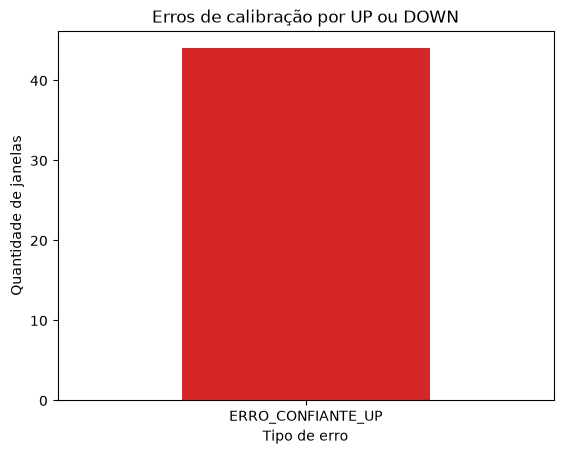

In [66]:

contagem_erros = df_alerta_calibracao['tipo_alerta'].value_counts()
contagem_erros.plot(kind='bar', color=['#d62728', '#1f77b4'])
plt.title('Erros de calibração por UP ou DOWN')
plt.xlabel('Tipo de erro')
plt.ylabel('Quantidade de janelas')
plt.xticks(rotation=0)
plt.show()


Nessa amostra, apenas foi possível captar casos onde a especulação estava para UP, mas o outcome real foi de DOWN. O caso contrário a esse não foi disparado no alerta com esses limites estabelecidos.

### Gráfico 2

Nesse próximo gráfico, olhei a distribuição de confiança das janelas que erraram, pra ver se os erros se concentram perto dos limites de 75%/25% ou se aparecem espalhados em níveis de confiança ainda mais extremos. Como apenas teve erros em relação ao lado UP, a confiança nas janelas que erraram ficaram entre mais ou menos 0,75 e 0,85.

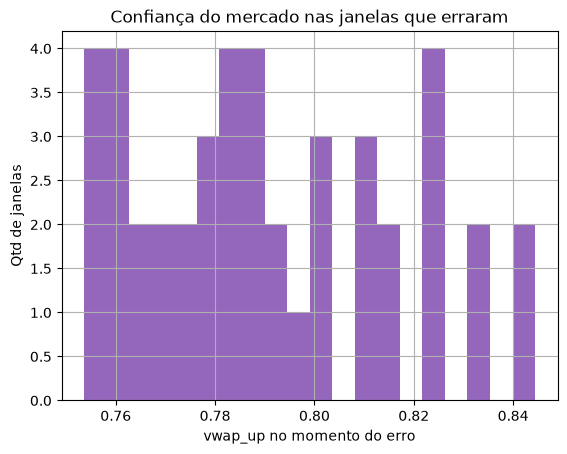

In [67]:
df_alerta_calibracao['vwap_up'].hist(bins=20, color='#9467bd')
plt.title('Confiança do mercado nas janelas que erraram')
plt.xlabel('vwap_up no momento do erro')
plt.ylabel('Qtd de janelas')
plt.show()


### Gráfico 3

Para o alerta de volume, olhei o quanto as janelas sinalizadas se distanciaram da média recente (medido em desvios padrão) e comparei com o padrão médio de volume por horário que já tinha levantado antes na consulta de dia da semana e hora.

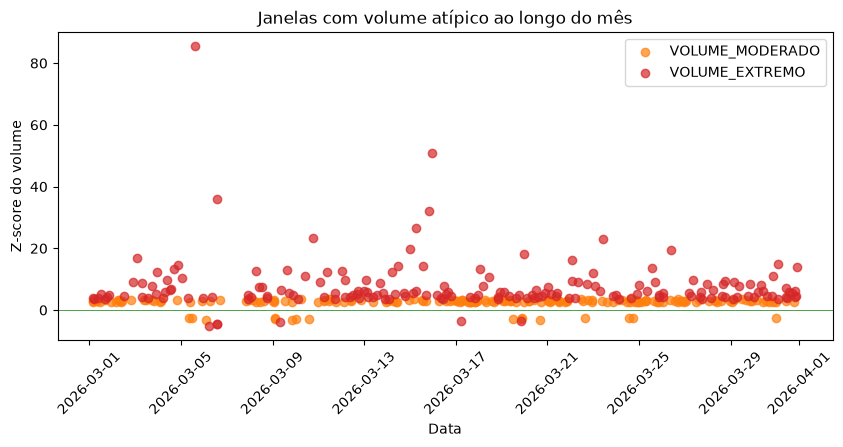

In [68]:
df_alerta_volume['end_date_ny'] = pd.to_datetime(df_alerta_volume['end_date_ny'])

cores = {'VOLUME_MODERADO': '#ff7f0e', 'VOLUME_EXTREMO': '#d62728'}
plt.figure(figsize=(10, 4))
for tipo, cor in cores.items():
    subset = df_alerta_volume[df_alerta_volume['tipo_alerta'] == tipo]
    plt.scatter(subset['end_date_ny'], subset['z_score'], label=tipo, color=cor, alpha=0.7)
plt.axhline(0, color='green', linewidth=0.5)
plt.title('Janelas com volume atípico ao longo do mês')
plt.xlabel('Data')
plt.ylabel('Z-score do volume')
plt.legend()
plt.xticks(rotation=45)
plt.show()


Podemos ver com essa distribuição que há muito mais pontos acima da média móvel (linha verde) do que abaixo, indicando que durante o mês houveram muitos picos de volume positivo do que negativo. Como já dito, a média móvel é calculada a partir da média das 24 últimas janelas de 5 minutos (2 horas).

### Gráfico 4

Agrupei os resultados da consulta de volume por dia da semana e hora, calculando a média do volume médio entre todos os dias do mês pra cada hora do dia, e plotei em um gráfico de barras. O objetivo aqui foi observar o mês inteiro condensado em 24 horas, pra ver de forma mais direta em quais horários do dia a negociação costuma ser mais forte, independente da data específica em que caiu.

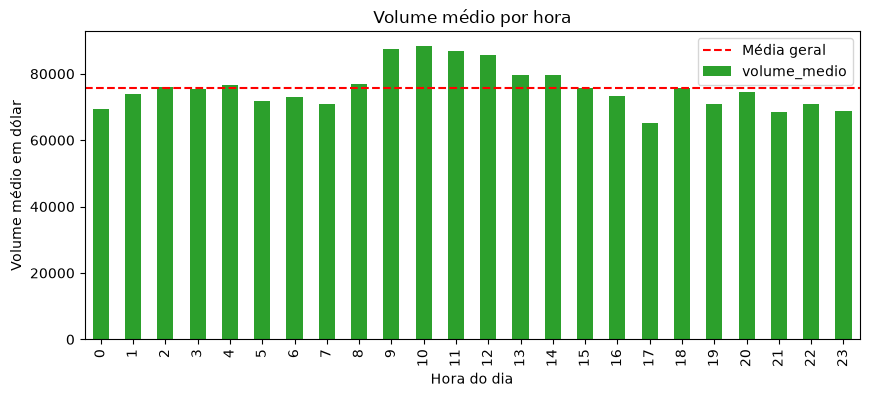

In [69]:
volume_por_hora = df_volume_horario.groupby('hora_ny')['volume_medio'].mean()
volume_por_hora.plot(kind='bar', figsize=(10, 4), color='#2ca02c')
plt.axhline(volume_por_hora.mean(), color='red', linestyle='--', label='Média geral')
plt.title('Volume médio por hora')
plt.xlabel('Hora do dia')
plt.ylabel('Volume médio em dólar')
plt.legend()
plt.show()

A partir desse gráfico, podemos ver que há uma boa ultrapassagem da média geral durante o intervalo de 9 às 12, indicando um possível horário de pico nesses mercados.

### Gráfico 5

De forma complementar ao gráfico 4, aqui eu plotei um heatmap com o volume médio, mas agora também com o dia da semana.

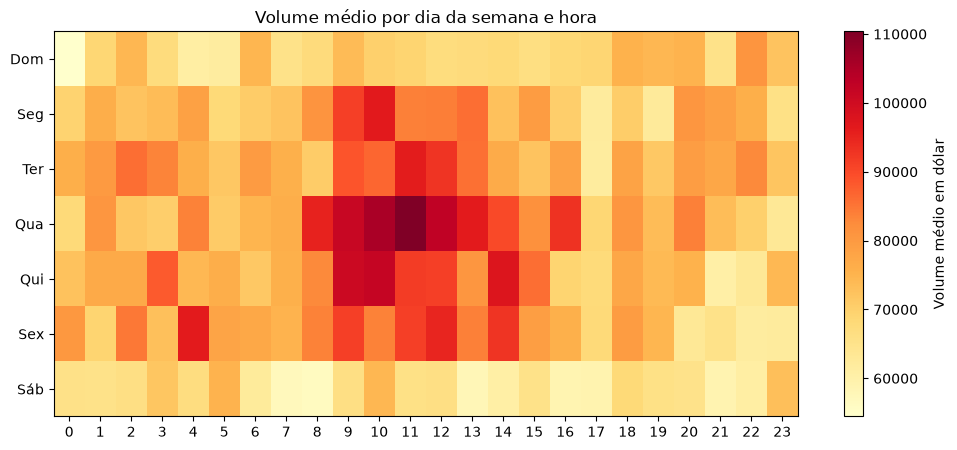

In [70]:
dias_semana = {1: 'Dom', 2: 'Seg', 3: 'Ter', 4: 'Qua', 5: 'Qui', 6: 'Sex', 7: 'Sáb'}
pivot_volume = df_volume_horario.pivot(
    index='dia_semana', columns='hora_ny', values='volume_medio'
).rename(index=dias_semana)
plt.figure(figsize=(12, 5))
plt.imshow(pivot_volume, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Volume médio em dólar')
plt.yticks(range(len(pivot_volume.index)), pivot_volume.index)
plt.xticks(range(len(pivot_volume.columns)), pivot_volume.columns)
plt.title('Volume médio por dia da semana e hora')
plt.show()

Nessa nossa amostra, o gráfico ainda reforça um possível horário de pico entre 9 e 12 horas, mas agora ele é enfatizado em certos dias da semana, em especial quarta-feira.

### Gráfico 6

Por fim, plotei as a oscilação média e a média de negociações, buscando encontrar algum comportamento irregular.

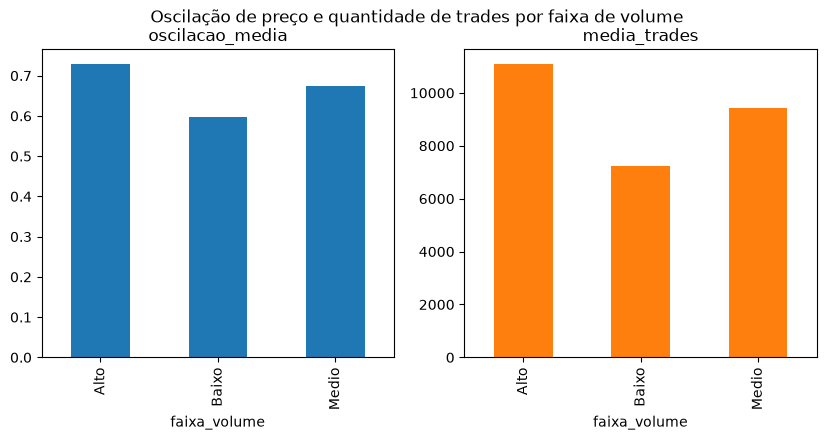

In [71]:
df_faixas_volume.set_index('faixa_volume')[['oscilacao_media', 'media_trades']].plot(
    kind='bar', subplots=True, layout=(1, 2), figsize=(10, 4), legend=False
)
plt.suptitle('Oscilação de preço e quantidade de trades por faixa de volume')
plt.show()


Após verificar os resultados, percebemos que há, aparentemente, um comportamento crescente entre essas duas métricas e a faixa de volume, indicando que volumes mais altos possuem maior oscilação e maior média de negociações.

## 6. Conclusão

Voltando às duas perguntas que guiaram a análise, a hipótese de volume se sustentou bem, pois o volume varia bastante ao longo do dia, com pico entre 9h e 12h que se repete nos diferentes dias da semana, e quanto maior a faixa de volume de uma janela, maior tende a ser tanto a oscilação de preço quanto a quantidade de negociações dentro dela. O segundo alerta reforça isso, mostrando que os desvios de volume não são raros ao longo do mês, com bem mais picos positivos do que negativos.

Já a hipótese de calibração parece se confirmar de forma mais modesta, visto que os erros de calibração encontrados foram poucos e concentrados num único lado (Up), o que indica que grandes erros de confiança não são um comportamento comum nos mercados de 5 minutos.

É importante destacar que esses comportamentos possivelmente podem não se repetir em mercados com outros intervalos de tempos (10 minutos, 15 minutos, 1 hora, etc), logo seria interessante uma análise comparativa, porém decidi manter fora do escopo desse relatório.